In [1]:
# Zachary Katz
# zachary_katz@mines.edu
# 11 June 2025

"""
Example notebook to download, filter, and plot seismic data at the time
of a Whillans event. Could be used with earthquake neural networks 
(e.g, EQTransformer; https://eqtransformer.readthedocs.io/en/latest/) 
to find events from before or after the GNSS stations were installed.

Revision History
v0.1 - 11 June 2025
    Initial Example notebook
"""

# Imports
import os
import obspy
from obspy.clients.fdsn.mass_downloader import Restrictions, MassDownloader, GlobalDomain

seismogram_path = './data/seismograms' # Set download path
xml_path = './data/stations' # Set XML path

In [2]:
# Earthquake files are typically in .mseed format
# Obspy can mass download seismic data from IRIS, where it is web hosted
# See https://docs.obspy.org/packages/autogen/obspy.clients.fdsn.mass_downloader.html#module-obspy.clients.fdsn.mass_downloader for more info
# Finding the network, station, location, and channel codes can be done with
# the IRIS metadata aggregator: https://ds.iris.edu/mda/

# For this example, we'll use station QSPA in network IU (https://ds.iris.edu/mda/IU/QSPA/)
# which is the south pole seismic station. The station page gives metadata, like
# location, instrument type, channel codes, and recording frequency.
# Lots of acronyms and abbreviations on this page -- just ask if you have questions!


# Manually set start time, number of days of data to download, and station info
start_time = obspy.UTCDateTime(2012, 1, 1)
days_to_download = 4
network = "IU" 
station = "QSPA" # South Pole seismic station
location = "00"
channel = "BH?" # ? is a wildcard for all channels starting with BH

# Set up to download from IRIS, using global domain because we're specifying
# specific stations
mdl = MassDownloader(providers=['IRIS'])
domain = GlobalDomain()

SEC_PER_DAY = 24 * 3600

# Download four days of data in one day chunks
for day in range(days_to_download):
    end_time = start_time + SEC_PER_DAY
    restrictions = Restrictions(
        starttime=start_time,
        endtime=end_time,
        chunklength_in_sec=SEC_PER_DAY, #1 day chunks
        network=network,
        station=station,
        location=location,
        channel=channel,
        reject_channels_with_gaps=False,
        minimum_length=0.0,
        minimum_interstation_distance_in_m=100.0 # Guard against same station having different names
        )
    mdl.download(domain, restrictions, mseed_storage=seismogram_path,
                stationxml_storage=xml_path,)
   
    start_time += SEC_PER_DAY # Update to next day

# Running this cell results in a folder with 3 channels * 4 days = 12 mseed files
# and a metadata folder with 1 stationxml file.

[2025-06-11 19:25:13,834] - obspy.clients.fdsn.mass_downloader - INFO: Initializing FDSN client(s) for IRIS.
[2025-06-11 19:25:14,244] - obspy.clients.fdsn.mass_downloader - INFO: Successfully initialized 1 client(s): IRIS.
[2025-06-11 19:25:14,248] - obspy.clients.fdsn.mass_downloader - INFO: Total acquired or preexisting stations: 0
[2025-06-11 19:25:14,250] - obspy.clients.fdsn.mass_downloader - INFO: Client 'IRIS' - Requesting reliable availability.
[2025-06-11 19:25:14,436] - obspy.clients.fdsn.mass_downloader - INFO: Client 'IRIS' - Successfully requested availability (0.19 seconds)
[2025-06-11 19:25:14,437] - obspy.clients.fdsn.mass_downloader - INFO: Client 'IRIS' - Found 1 stations (3 channels).
[2025-06-11 19:25:14,438] - obspy.clients.fdsn.mass_downloader - INFO: Client 'IRIS' - Will attempt to download data from 1 stations.
[2025-06-11 19:25:14,440] - obspy.clients.fdsn.mass_downloader - INFO: Client 'IRIS' - Status for 3 time intervals/channels before downloading: NEEDS_DO

In [3]:
# Load seismograms
inv =  obspy.read_inventory("./data/stations/*")
stream = obspy.Stream()

for trace_index in range(days_to_download):
    st_index = trace_index * 3  # Each day has 3 channels
    ed_index = trace_index * 3 + 3 
    for file in os.listdir(seismogram_path)[st_index:ed_index]:
        # Each mseed file may contain multiple traces that need to be combined
        temp_stream = obspy.read(f'{seismogram_path}/{file}')
        temp_stream.attach_response(inv)
        t1 = temp_stream[0]
    
        for trace in temp_stream[1:]:
            t1 = t1.__add__(trace, method=1,fill_value=0)
        stream.append(t1)

# Seperate into North, South, and Vertical components
stream.sort()
N = stream.select(channel='BH1')
E = stream.select(channel='BH2')
Z = stream.select(channel='BHZ')

# Make daily streams
day_streams = []
for day in range(len(N)):
    day_stream = obspy.Stream(traces=[N[day],E[day],Z[day]])
    day_streams.append(day_stream)
        



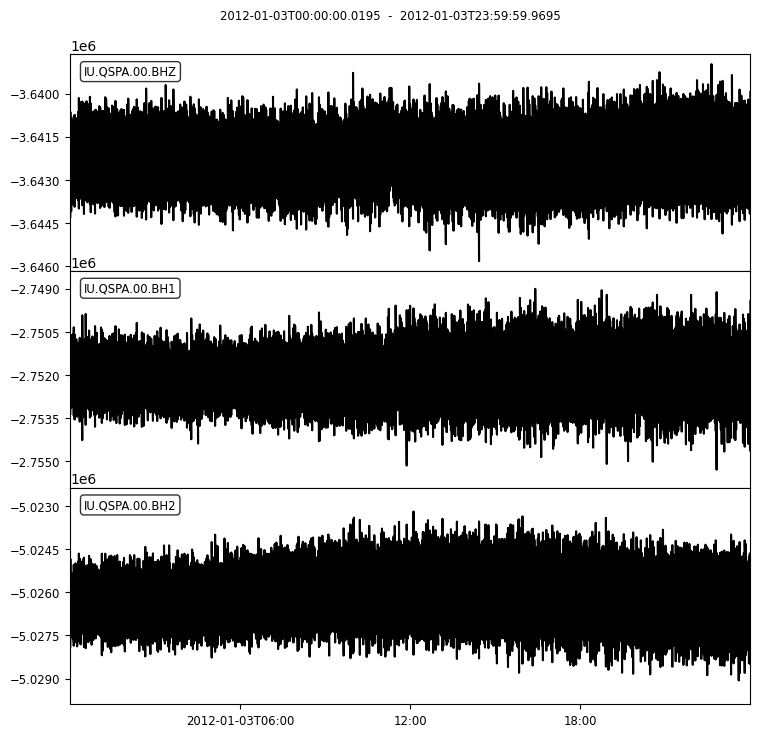

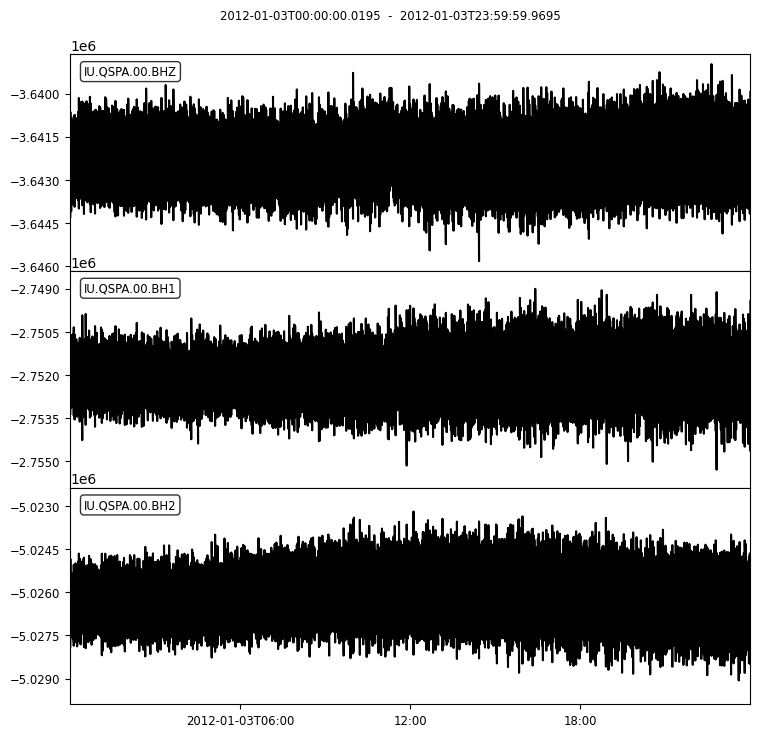

In [9]:
# Example plot - still looks like noise because we haven't filtered yet
day_streams[2].plot()

In [10]:
# Filter and crop to Whillans event
# 2012-01-02 09:21:15, grabbed from Event Start Time list. Could also find programmatically
whillans_event_time = obspy.UTCDateTime("2012-01-02T09:21:15")
# Filter and trim
filtered_days = []
for day_stream in day_streams:
        filtered = day_stream.copy() # Filtering and trimming is done 'in place'
        #filt.remove_response() # Expensive!
        filtered.filter("bandpass", freqmin=1/100,freqmax=1/30) # Freqmin freqmax from Pratt et al., 2014
        filtered.trim(starttime=whillans_event_time - 3600, endtime=whillans_event_time +3600)
        filtered_days.append(filtered)

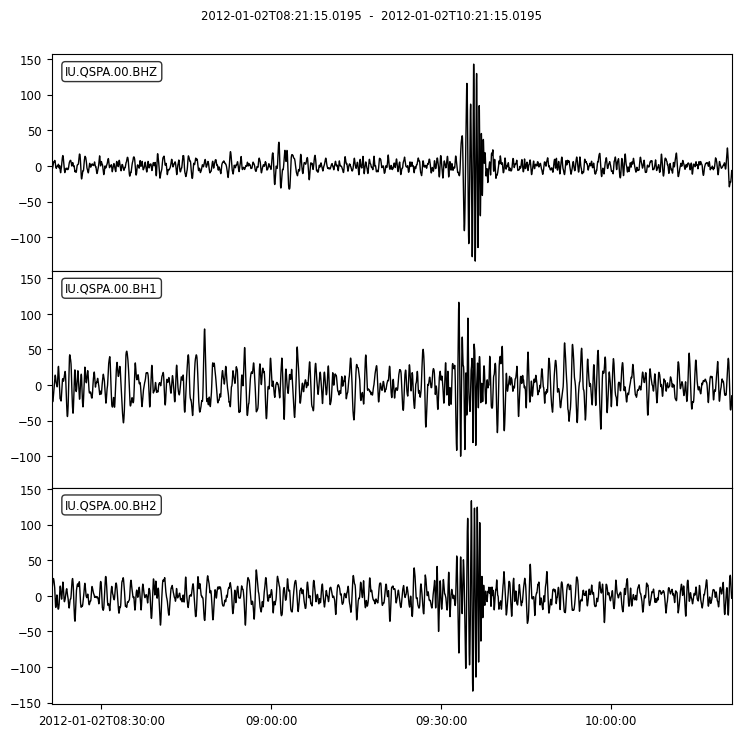

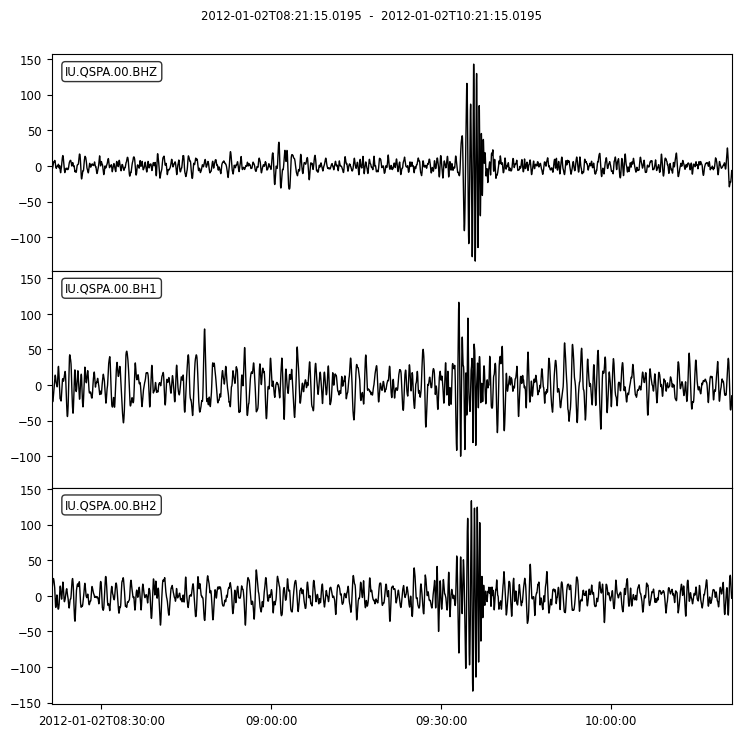

In [11]:
# Now we can see what is likely the event (cross check with earthquakes from USGS 
# to make sure not a teleseismic event https://earthquake.usgs.gov/earthquakes/search/)
filtered_days[1].plot()

# Can also extract for plotting in, e.g., matplotlib